# Exploratory Data Analysis — Breast Cancer Classification

This notebook is exploration only. Nothing here is imported into the production
pipeline (`src/`) — it exists to document what we observed in the data and what
that implies for modeling choices made in `src/features/preprocessing.py` and
`src/models/train.py`.

Data: Wisconsin Diagnostic Breast Cancer (WDBC) dataset, loaded through our own
validated data layer (`src.data.load_data`) rather than directly from sklearn,
so this notebook is looking at exactly the same data the pipeline trains on.

In [1]:
import sys
sys.path.insert(0, "..")

import os
os.environ.setdefault("DISABLE_PANDERA_IMPORT_WARNING", "True")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_validated_dataframe
from src.data.schema import TARGET_COLUMN, FEATURE_COLUMNS

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

df = load_validated_dataframe()
df.shape

2026-09-20 14:11:24 | INFO     | src.data.load_data | Loaded raw dataset: 569 rows, malignant=212, benign=357
2026-09-20 14:11:24 | INFO     | src.data.validate | Data validation passed: 569 rows, 31 columns


(569, 31)

## 1. Class balance

target
benign       357
malignant    212
Name: count, dtype: int64

target
benign       62.7%
malignant    37.3%
Name: count, dtype: object


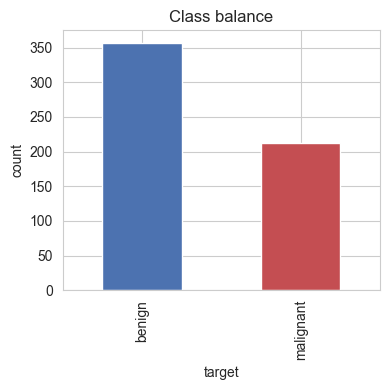

In [2]:
counts = df[TARGET_COLUMN].value_counts().rename({0: "benign", 1: "malignant"})
counts_pct = (counts / counts.sum() * 100).round(1)
print(counts)
print()
print(counts_pct.astype(str) + "%")

fig, ax = plt.subplots(figsize=(4, 4))
counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

**Observation:** ~63% benign / ~37% malignant. This is a mild imbalance — not
severe enough to require aggressive resampling, but enough that accuracy alone
would be misleading (a model that always predicts "benign" scores ~63%
accuracy while catching zero cancer cases). This is why `src/models/evaluate.py`
treats **recall on the malignant class** as the primary metric, and why
`src/features/preprocessing.py` supports both class-weighting and SMOTE as
configurable imbalance-handling strategies.

## 2. Feature distributions by class

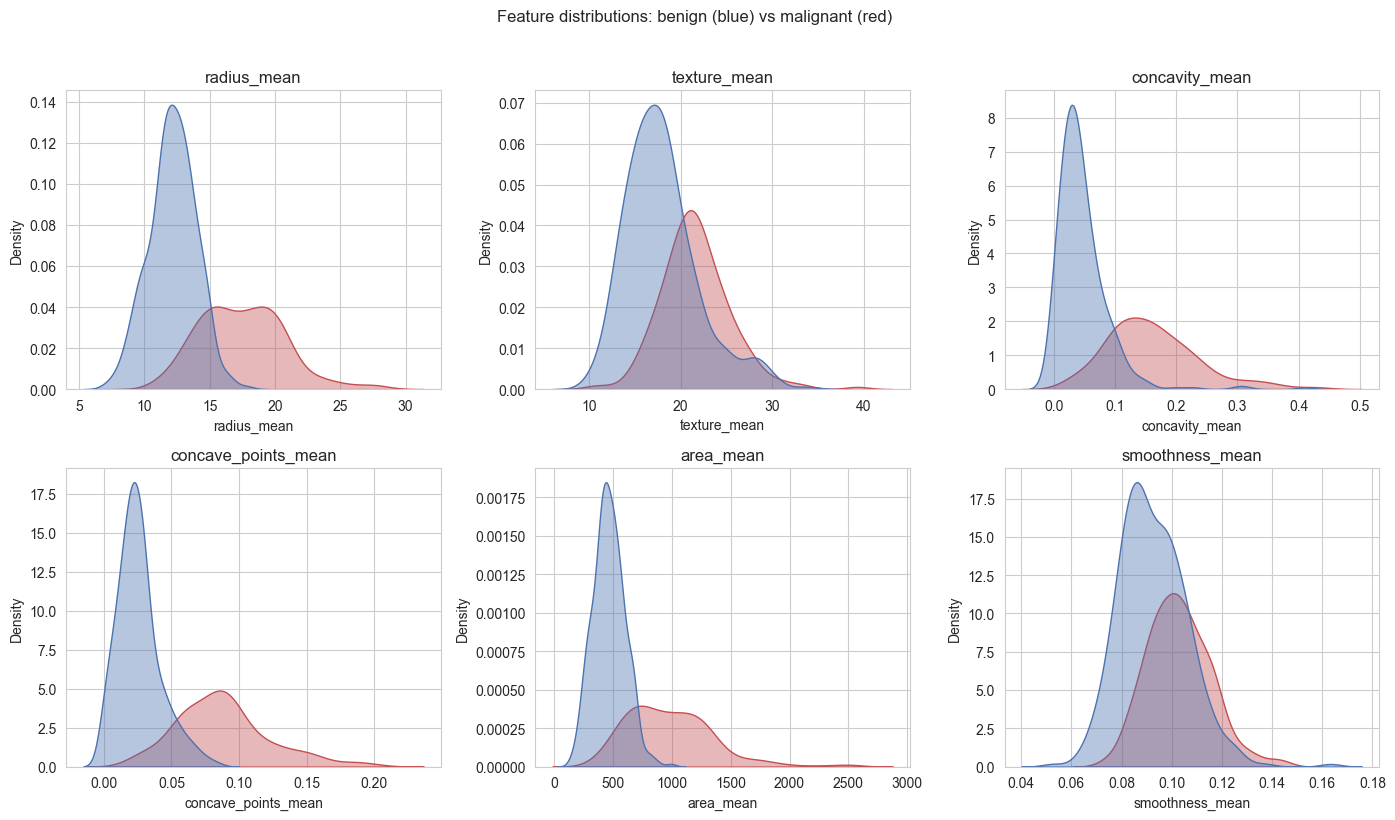

In [3]:
key_features = [
    "radius_mean", "texture_mean", "concavity_mean",
    "concave_points_mean", "area_mean", "smoothness_mean",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.kdeplot(data=df, x=feat, hue=TARGET_COLUMN, ax=ax, fill=True, alpha=0.4,
                palette={0: "#4C72B0", 1: "#C44E52"}, legend=False)
    ax.set_title(feat)
fig.suptitle("Feature distributions: benign (blue) vs malignant (red)", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** malignant cases show visibly higher `radius_mean`,
`concavity_mean`, and `concave_points_mean`, with less overlap between classes
on these features than on `smoothness_mean` or `texture_mean`. This is
consistent with the clinical intuition that malignant masses tend to be larger
and more irregularly shaped (higher concavity), and it foreshadows what the
SHAP analysis in `src/explainability/shap_explain.py` later confirms
quantitatively.

## 3. Correlation structure

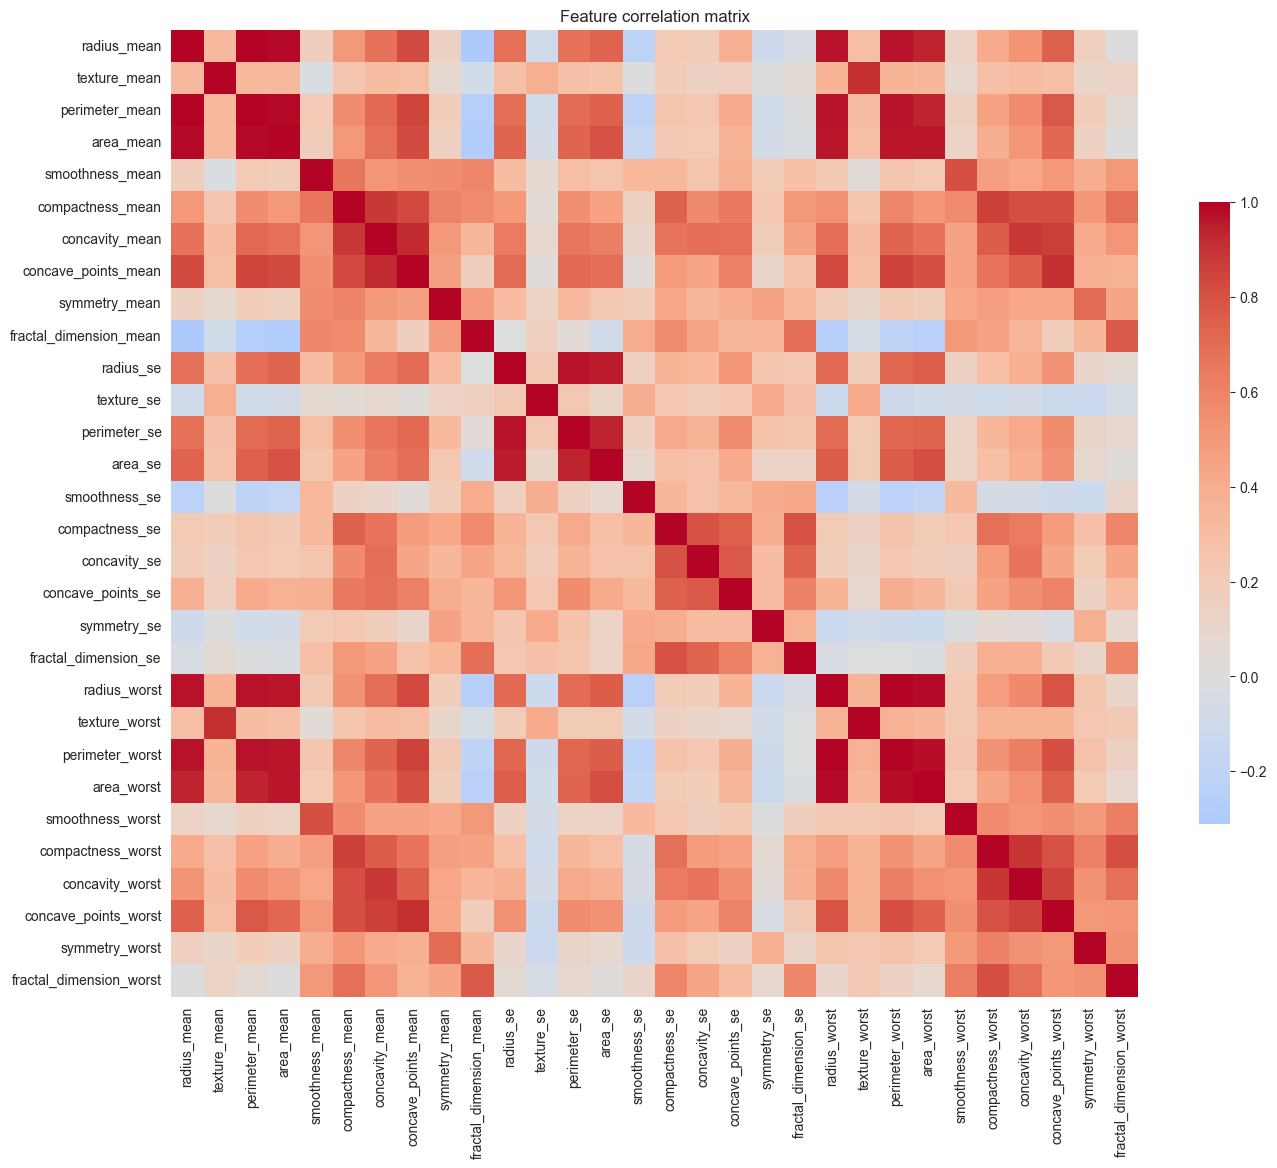

In [4]:
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [5]:
# Which feature pairs are most strongly (anti)correlated?
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs.reindex(corr_pairs["correlation"].abs().sort_values(ascending=False).index).head(10)

,feature_1,feature_2,correlation
1,radius_mean,perimeter_mean,0.997855
391,radius_worst,perimeter_worst,0.993708
2,radius_mean,area_mean,0.987357
57,perimeter_mean,area_mean,0.986507
392,radius_worst,area_worst,0.984015
407,perimeter_worst,area_worst,0.977578
246,radius_se,perimeter_se,0.972794
76,perimeter_mean,perimeter_worst,0.970387
19,radius_mean,radius_worst,0.969539
74,perimeter_mean,radius_worst,0.969476


**Observation:** `radius`, `perimeter`, and `area` (across mean/se/worst) are
extremely highly correlated with each other, which is expected — they're
different ways of measuring the same physical size. This multicollinearity
matters for model choice: it can inflate coefficient variance in **logistic
regression** (though L2 regularization, which `src/models/tune.py` searches
over via `C`, controls this), while **tree-based models** (random forest,
XGBoost) are largely insensitive to it since they split on one feature at a
time rather than fitting linear coefficients across all of them jointly.
This is part of the justification for comparing both model families in
`src/models/train.py` rather than committing to one upfront.

## 4. Outlier check

2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y=feat, ax=ax,
C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["benign", "malignant"])
C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y=feat, ax=ax,


2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-20 14:26:08 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["benign", "malignant"])
C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y=feat, ax=ax,
C:\Users\user\AppData\Local\Temp\ipykernel_13976\2325185611.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["benign", "malignant"])


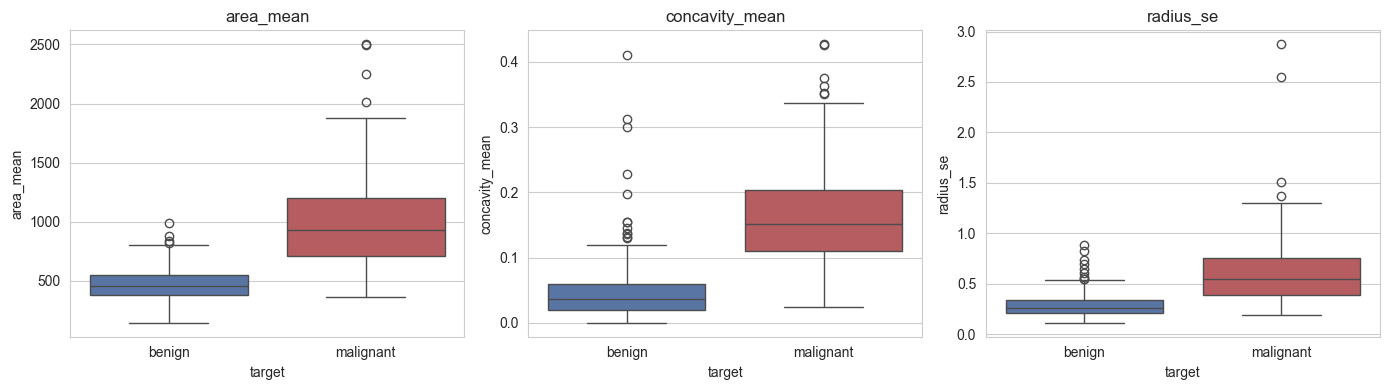

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ["area_mean", "concavity_mean", "radius_se"]):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=feat, ax=ax,
                palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["benign", "malignant"])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Observation:** malignant cases have both higher medians and wider spread on
`area_mean` and `concavity_mean` — the outliers on the high end are almost
entirely malignant cases, not data errors. This means we should NOT
aggressively clip or remove outliers here; they carry real signal. This
directly informed the data validation schema in `src/data/schema.py`, which
checks for physically implausible values (negative measurements, extreme unit
errors) rather than statistically "unusual" ones — we validate for
correctness, not for typicality.

## 5. Summary — implications for modeling

1. **Imbalance is mild (63/37), not severe** — class-weighting is a reasonable
   default; SMOTE is offered as a configurable alternative but not strictly
   required.
2. **Recall on malignant is the metric that matters**, not accuracy — a naive
   majority classifier would look deceptively good on accuracy alone.
3. **Multicollinearity among size-related features is high** — justifies
   comparing a regularized linear model against tree-based models rather than
   assuming one is obviously better.
4. **Outliers carry real signal, not noise** — the data validation layer
   checks plausibility (non-negative, bounded), not statistical
   typicality, so real extreme-but-valid malignant cases are never
   incorrectly filtered out.